In [1]:
from sympy import symbols, Rational
from sympy.utilities.codegen import codegen
from sympy.codegen.rewriting import optimize, optims_c99
from sympy.simplify.cse_main import cse
import sympy as sp
from sympy import S
from sympy.printing.c import C99CodePrinter, Assignment
from sympy import init_printing
from codegen.codegen_utils import * 
init_printing()
printer = MyPrinter() 


In [2]:
M, rc, Tc, uc, gamma, n, K, T, r= symbols("M rc Tc uc gamma n K T r")

scalar = ("double", None)
ABI = {
    "M": scalar,
    "rc": scalar,
    "gamma": scalar,
    "n": scalar,
    "K": scalar,
    "T": scalar,
    "r": scalar,
    "Tc": scalar,
    "uc": scalar
}

In [3]:
u1_c = - sp.sqrt(M/(2*rc))
T_c = n/(n+1) * (u1_c**2)/(1-(n+3)*u1_c**2) 

In [4]:
C1 = Tc**n * uc * rc**2 
C2 = (1+(n+1)*Tc)**2*(1-2*M/rc + uc**2)

In [7]:
f = sp.simplify((1+(n+1)*T)**2*(1-2*M/r + C1**2/(r**4*T**(2*n))) - C2)
#f = sp.simplify(f)
df_dT = sp.simplify(f.diff(T))

In [8]:
u1 = C1/(r**2*T**n)
rho = (T/K)**n 
p = T * rho 

In [11]:
flist = []

out_list = ["dT","dT_dr"]
out_abi = {"dT": scalar, "dT_dr": scalar}
flist.append(make_function([f,df_dT],printer,"bondi_T__r",ABI,out_list,out_abi))

out_list = ["ur","rho","press"]
out_abi = {"ur": ("double",None), "rho": ("double",None), "press": ("double",None)}
flist.append(make_function([u1,rho,p],printer,"bondi_ur_rho_p__r",ABI,out_list,out_abi))


out_list = ["ur_c","T_c"]
out_abi = {"ur_c": ("double",None), "T_c": ("double",None)}
flist.append(make_function([u1_c,T_c],printer,"bondi_uc_Tc",ABI,out_list,out_abi))

printed_functions = '\n' + '\n'.join(flist)

In [12]:
file = '''
/****************************************************************************/
/*                     Bondi ID helpers, SymPy generated                    */
/****************************************************************************/
#ifndef GRACE_BONDI_ID_SUBEXPR_HH
#define GRACE_BONDI_ID_SUBEXPR_HH

#include <Kokkos_Core.hpp>
''' + printed_functions + '''
#endif 
'''
with open("bondi_subexpressions.hh","w") as ff:
    ff.write(file)

In [ ]:
f.subs({M:1, n:3, rc:8, Tc:0.075, uc: -0.25, r: 7.979946872679769, T: 0.07500420039979833})

In [ ]:
T__r = sp.lambdify([rc,gamma,n,K,M,T,r,uc,Tc],f)
dT__r = sp.lambdify([rc,gamma,n,K,M,T,r,uc,Tc],df_dT)

T_c__l = sp.lambdify([rc,gamma,n,K,M],T_c)
u_c__l = sp.lambdify([rc,gamma,n,K,M],u1_c)

In [ ]:
Gamma = 4/3 
NN = 1/((Gamma-1))
KK = 1
RC = 8 

In [ ]:
TC = T_c__l(RC,Gamma,NN,KK,1)
UC = u_c__l(RC,Gamma,NN,KK,1)
AS = 1/(2*RC-3)
print(AS)

0.07692307692307693


In [ ]:
from scipy.optimize import newton 
import numpy as np 
rotfun = lambda T,r: T__r(RC,Gamma,NN,K,1,T,r,UC,TC) 
drotfun = lambda T,r: dT__r(RC,Gamma,NN,K,1,T,r,UC,TC) 

In [ ]:
TT = [] 
RR = [] 
# Solve down 
radii_m = np.linspace(3,7.5,100)
for i,rr in enumerate(radii_m[::-1]):
    Tguess = TT[-1]*(1+1e-6) if i>0 else TC*(1+1e-6)
    TT.append(newton(rotfun,Tguess,args=[rr]))
    RR.append(rr)
TT = TT[::-1]
RR = RR[::-1]
# Solve up 
radii_p = np.linspace(8.5,20,100)
for i,rr in enumerate(radii_p):
    Tguess = TT[-1]*(1-1e-6) if i>0 else TC*(1-1e-6)
    TT.append(newton(rotfun,Tguess,args=[rr]))
    RR.append(rr)

TT = np.array(TT)
RR = np.array(RR)

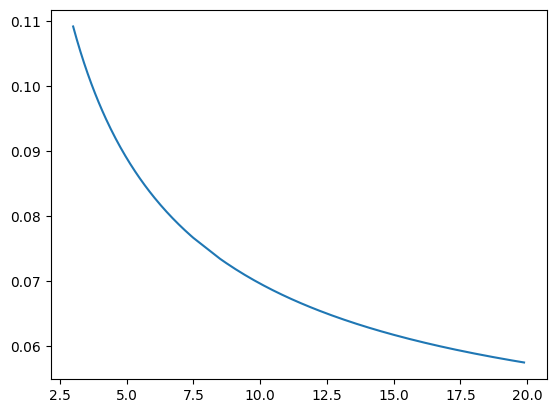

In [ ]:
import matplotlib.pyplot as plt 
plt.plot(RR[:-1],TT[:-1])

In [ ]:
rho = (TT/KK)**NN 
pg = TT * rho 
ur = C1.subs({rc: RC, M: 1, n: NN})/(RR**2 * TT**NN)
h = 1 + TT/(Gamma-1) + pg/rho 
csnd2 = Gamma * pg / (rho*h)